In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('risk.csv')

In [3]:
df

,Code,Parent,Children,Total
0,Depictions of physical violence in game,234,283,517
1,Ineffective game/community moderation,252,157,409
2,"Bullying, harassment, trolling from other players",163,228,391
3,Leaking/scamming to get personal information,149,230,379
4,Gaming becoming online dating for kids,129,200,329
5,Sexual game content for children,127,172,299
6,Game design features that encourage children t...,131,100,231
7,Sexual and explicit conversations,82,135,217
8,Encountering online strangers without supervision,78,78,156
9,Hacking user account,56,99,155


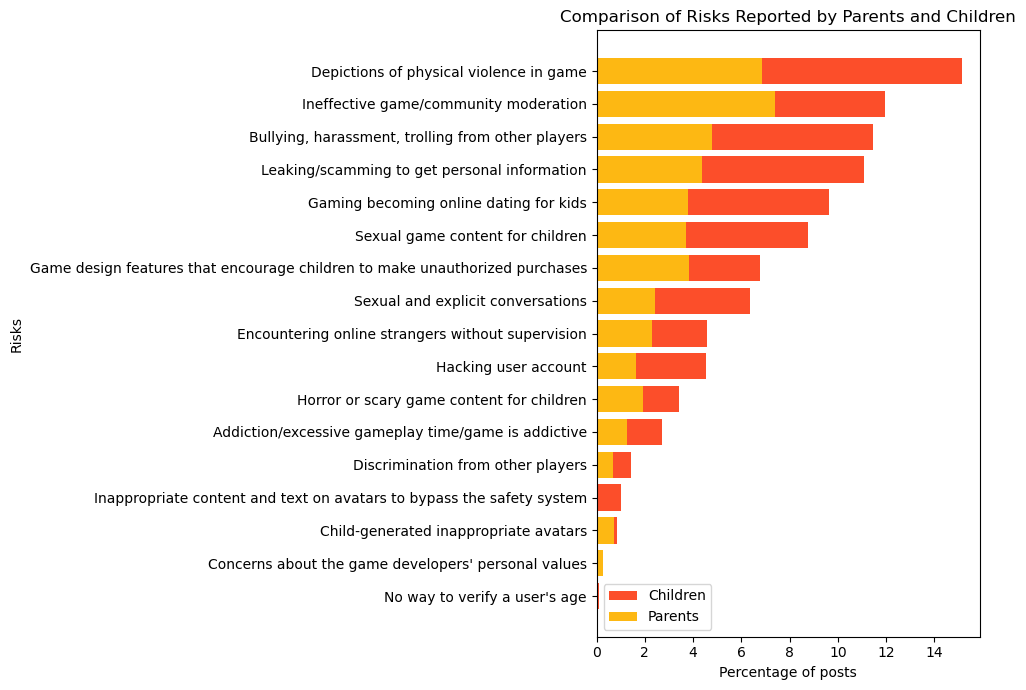

In [4]:
# horizon bar plot 
import matplotlib.pyplot as plt
# Convert to percentage
grand_total = df["Total"].sum()
df["Children_pct"] = df["Children"] / grand_total * 100
df["Parent_pct"] = df["Parent"] / grand_total * 100

df_sorted = df.sort_values("Total", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(df_sorted["Code"], df_sorted["Children_pct"], 
        left=df_sorted["Parent_pct"], color="#FC4E2A", label="Children")
ax.barh(df_sorted["Code"], df_sorted["Parent_pct"], 
        color="#FDB813", label="Parents")

ax.set_xlabel("Percentage of posts")
ax.set_ylabel("Risks")
ax.set_title("Comparison of Risks Reported by Parents and Children")
ax.legend()

plt.tight_layout()
plt.show()

## ANOVA Test

In [5]:
# Anova  Split: top-6 (by Total) vs rest ----
df_sorted = df.sort_values("Total", ascending=False)
top6 = df_sorted.head(6)
rest = df_sorted.iloc[6:]  #

import scipy.stats as stats

In [6]:
# One-way ANOVA: for top-6 risk vs pooled "rest"
F_parent, p_parent = stats.f_oneway(top6["Parent"].values, rest["Parent"].values)
F_child,  p_child  = stats.f_oneway(top6["Children"].values, rest["Children"].values)

# Calculate effect sizes (eta-squared)
def calculate_eta_squared(group1, group2):
    """Calculate eta-squared (η²) effect size for two groups"""
    all_data = np.concatenate([group1, group2])
    grand_mean = np.mean(all_data)
    
    # Sum of squares between groups
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    ss_between = n1 * (mean1 - grand_mean)**2 + n2 * (mean2 - grand_mean)**2
    
    # Sum of squares total
    ss_total = np.sum((all_data - grand_mean)**2)
    
    # Eta-squared
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    return eta_squared

import numpy as np
eta_sq_parent = calculate_eta_squared(top6["Parent"].values, rest["Parent"].values)
eta_sq_child = calculate_eta_squared(top6["Children"].values, rest["Children"].values)

print(f"ANOVA (Parents):  F = {F_parent:.4f}, p = {p_parent:.6f}, η² = {eta_sq_parent:.4f}")
print(f"ANOVA (Children): F = {F_child:.4f}, p = {p_child:.6f}, η² = {eta_sq_child:.4f}")

ANOVA (Parents):  F = 31.0891, p = 0.000053, η² = 0.6745
ANOVA (Children): F = 47.7914, p = 0.000005, η² = 0.7611


In [13]:
# ---- (Optional) Welch's t-test gives equivalent inference for 2 groups ----
from scipy.stats import ttest_ind
t_parent, tp_parent = ttest_ind(top6["Parent"].values, rest["Parent"].values, equal_var=False)
t_child,  tp_child  = ttest_ind(top6["Children"].values, rest["Children"].values, equal_var=False)
print(f"Welch t-test (Parents):  t = {t_parent:.4f}, p = {tp_parent:.6f}")
print(f"Welch t-test (Children): t = {t_child:.4f}, p = {tp_child:.6f}")

Welch t-test (Parents):  t = 5.1080, p = 0.000861
Welch t-test (Children): t = 6.8910, p = 0.000037
